 # Deep Learning - Assignment 3
 ## Lyrics Generation using RNNs

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import pretty_midi
import os
import re
import random
from tqdm import tqdm
from gensim.models import Word2Vec

In [21]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 1. Data Loading and Preprocessing

In [22]:
# Load lyrics data
def load_lyrics_data(file_path):
    """Load lyrics data from CSV file."""
    df = pd.read_csv(file_path, header=None, usecols=[0, 1, 2])
    df.columns = ['artist', 'song', 'lyrics']
    return df


def is_problematic(row):
    # List of known problematic files (patterns to match in filenames)
    problematic_patterns = [
        ('beastie boys', 'girls'),
        ('billy joel', 'movin\' out'),
        ('billy joel', 'pressure'),
        ('dan fogelberg', 'leader of the band'),
        ('brian mcknight', 'on the down low'),
        ('aaron neville', 'tell it like it is'),
    ]

    return (row['artist'].lower(), row['song'].lower()) in problematic_patterns


train_lyrics = load_lyrics_data('data/lyrics_train_set.csv')
train_lyrics = train_lyrics[~train_lyrics.apply(is_problematic, axis=1)].reset_index(drop=True)

test_lyrics = load_lyrics_data('data/lyrics_test_set.csv')

# Display sample of the data
print("Training data shape:", train_lyrics.shape)
print("Test data shape:", test_lyrics.shape)

Training data shape: (594, 3)
Test data shape: (5, 3)


In [23]:
# Function to load and extract features from MIDI files
def load_midi_features(midi_file_path):
    """Extract features from a MIDI file using pretty_midi."""
    midi_data = pretty_midi.PrettyMIDI(midi_file_path)

    # Basic MIDI features
    features = {}

    # Tempo information
    tempo_changes = midi_data.get_tempo_changes()
    features['tempo'] = np.mean(tempo_changes[1])

    # Extract note features from the first instrument (assuming melody)
    notes = []

    for inst in midi_data.instruments:
        for note in inst.notes:
            notes.append({
                'pitch': note.pitch,
                'start': note.start,
                'end': note.end,
                'duration': note.end - note.start,
                'velocity': note.velocity
            })
        # Convert to numpy arrays for easier manipulation
        if notes:
            pitches = np.array([note['pitch'] for note in notes])
            durations = np.array([note['duration'] for note in notes])
            velocities = np.array([note['velocity'] for note in notes])
            features['avg_pitch'] = np.mean(pitches)
            features['pitch_std'] = np.std(pitches)
            features['pitch_range'] = np.max(pitches) - np.min(pitches)
            features['avg_duration'] = np.mean(durations)
            features['avg_velocity'] = np.mean(velocities)
            features['note_density'] = len(notes) / midi_data.get_end_time()
            # Store the sequence of notes (for detailed melody representation)
            features['note_sequence'] = [
                {'pitch': note.pitch,
                 'start': note.start,
                 'duration': note.end - note.start,
                 'velocity': note.velocity}
                for note in inst.notes
            ]

    return features

In [24]:
# Test MIDI feature extraction on a sample file
midi_files_dir = 'data/midi_files'
sample_midi_file = os.path.join(midi_files_dir, os.listdir(midi_files_dir)[0])
print(f"Testing feature extraction on: {sample_midi_file}")
sample_features = load_midi_features(sample_midi_file)

for key, value in sample_features.items():
    if key != 'note_sequence':
        print(f"{key}: {value}")
print(f"Number of notes in sequence: {len(sample_features['note_sequence'])}")

Testing feature extraction on: data/midi_files\1910_Fruitgum_Company_-_Simon_Says.mid
tempo: 135.000135000135
avg_pitch: 60.3775082359988
pitch_std: 14.32627598325973
pitch_range: 62
avg_duration: 0.23320713371331242
avg_velocity: 119.95941898772088
note_density: 42.14915457519008
Number of notes in sequence: 78


## 2. Data Preprocessing

In [25]:
# Process lyrics into tokenized format
def preprocess_lyrics(lyrics_series):
    """Preprocess and tokenize lyrics."""
    all_lyrics = []
    for lyric in lyrics_series:
        # Convert to lowercase and split into lines
        lyric = str(lyric).lower()
        lines = lyric.split('&')

        # Process each line
        for line in lines:
            # Clean and tokenize
            # tokens = re.findall(r'\b\w+\b', line)
            tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
            if tokens:  # Skip empty lines
                all_lyrics.append(tokens)

    return all_lyrics


# Process train and test lyrics
train_tokenized = preprocess_lyrics(train_lyrics.iloc[:, 2])
test_tokenized = preprocess_lyrics(test_lyrics.iloc[:, 2])

print(f"Number of lines in training set: {len(train_tokenized)}")
print(f"Number of lines in test set: {len(test_tokenized)}")

Number of lines in training set: 23659
Number of lines in test set: 189


In [26]:
# Build vocabulary
def build_vocabulary(tokenized_lyrics, min_freq=2):
    """Build vocabulary from tokenized lyrics."""
    word_counts = Counter()
    for line in tokenized_lyrics:
        word_counts.update(line)

    vocab = {'<PAD>': 0, '<NEXT LINE>': 1, '<START>': 2, '<END>': 3}
    idx = 4

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab, word_counts


vocab, word_counts = build_vocabulary(train_tokenized, min_freq=0)
print(f"Vocabulary size: {len(vocab)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Vocabulary size: 7384
Top 10 most common words: [('you', 5898), ('the', 5805), ('i', 5290), ('to', 3733), ('and', 3654), ('a', 3063), ('me', 2817), ('my', 2161), ('it', 2051), ('in', 2039)]


In [27]:
print("Training custom Word2Vec model on lyrics dataset...")
# You can adjust these parameters based on your needs
embedding_dim = 300
window_size = 5
min_count = 1  # Can be set to match your min_freq in build_vocabulary
workers = 4  # Number of CPU cores to use

# Train the model
custom_w2v_model = Word2Vec(
    sentences=train_tokenized,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    workers=workers,
    sg=1,  # Skip-gram model (use CBOW with sg=0)
    epochs=20
)

print(f"Custom Word2Vec model trained with vector size: {custom_w2v_model.vector_size}")
print(f"Vocabulary size in Word2Vec model: {len(custom_w2v_model.wv.key_to_index)}")


# Create embedding matrix for our vocabulary
def create_embedding_matrix(vocab, embedding_model, embedding_dim=300):
    """Create embedding matrix for words in vocabulary."""
    embedding_matrix = np.zeros((len(vocab), embedding_dim))
    for word, idx in vocab.items():
        # Use the word vectors from your custom model
        if word in embedding_model.wv:
            embedding_matrix[idx] = embedding_model.wv[word]
        elif word not in ['<PAD>', '<NEXT LINE>', '<START>', '<END>'] and word.lower() in embedding_model.wv:
            embedding_matrix[idx] = embedding_model.wv[word.lower()]

    # Initialize special tokens with random values
    for special_token in ['<NEXT LINE>', '<START>', '<END>']:
        embedding_matrix[vocab[special_token]] = np.random.uniform(-0.25, 0.25, embedding_dim)

    return embedding_matrix


embedding_matrix = create_embedding_matrix(vocab, custom_w2v_model)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Training custom Word2Vec model on lyrics dataset...
Custom Word2Vec model trained with vector size: 300
Vocabulary size in Word2Vec model: 7380
Embedding matrix shape: (7384, 300)


## 3. Match Lyrics with MIDI Files

In [28]:
# Create a mapping between lyrics and midi files
def create_lyrics_midi_mapping(lyrics_df, midi_dir):
    """Create mapping between lyrics and MIDI files."""
    mapping = []

    # Get list of MIDI files
    midi_files = os.listdir(midi_dir)

    # For each song in the lyrics dataset, find the matching MIDI file
    for idx, row in lyrics_df.iterrows():
        artist = row['artist'].strip().lower().replace(' ', '_')
        song = row['song'].strip().lower().replace(' ', '_')
        lyrics = row['lyrics']

        # Look for matching MIDI file
        for midi_file in midi_files:
            midi_name = midi_file.lower()
            if artist in midi_name and song in midi_name:
                mapping.append({
                    'artist': artist,
                    'song': song,
                    'lyrics': lyrics,
                    'midi_file': os.path.join(midi_dir, midi_file)
                })
                break

    return mapping


# Create mapping for training and test data
train_mapping = create_lyrics_midi_mapping(train_lyrics, midi_files_dir)
test_mapping = create_lyrics_midi_mapping(test_lyrics, midi_files_dir)

print(f"Found matching MIDI files for {len(train_mapping)} out of {len(train_lyrics)} training songs")
print(f"Found matching MIDI files for {len(test_mapping)} out of {len(test_lyrics)} test songs")

Found matching MIDI files for 594 out of 594 training songs
Found matching MIDI files for 5 out of 5 test songs


 ## 4. Prepare Dataset for Training

In [29]:
# Custom Dataset class
class LyricsMelodyDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50):
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        """Process all data at initialization."""
        self.data = []

        for mapping in tqdm(self.mappings, desc="Processing data"):
            # Extract midi features
            midi_features = load_midi_features(mapping['midi_file'])

            # Process lyrics
            lyrics = str(mapping['lyrics']).lower()
            lines = lyrics.split('&')

            # Create one long sequence with special tokens
            all_tokens = ['<START>']

            for line in lines:
                line_tokens = re.findall(r"\b\w+(?:'\w+)*\b", line)
                if line_tokens:  # Skip empty lines
                    all_tokens.extend(line_tokens)
                    all_tokens.append('<NEXT LINE>')

            # Replace the last NEXT_LINE with END
            if all_tokens[-1] == '<NEXT LINE>':
                all_tokens[-1] = '<END>'
            else:
                all_tokens.append('<END>')

            # Convert to indices
            indices = [self.vocab[token] for token in all_tokens]

            # Create input-target pairs across the entire sequence
            for i in range(len(indices) - 1):
                # Input: current word
                input_word = indices[i]
                # Target: next word
                target_word = indices[i + 1]

                # Add to data with melody features
                self.data.append({
                    'input_word': input_word,
                    'melody_features': midi_features,
                    'target_word': target_word,
                    'position': i,
                    'line_length': len(indices)
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Extract melody features (simplified representation for now)
        melody_feats = np.array([
            item['melody_features']['avg_pitch'],
            item['melody_features']['pitch_std'],
            item['melody_features']['pitch_range'],
            item['melody_features']['avg_duration'],
            item['melody_features']['avg_velocity'],
            item['melody_features']['note_density'],
            item['melody_features']['tempo'] / 120.0,  # Normalize tempo
        ])

        # For the first approach (simplistic), we'll use these basic features

        return {
            'input_word': torch.tensor(item['input_word'], dtype=torch.long),
            'melody_features': torch.tensor(melody_feats, dtype=torch.float),
            'target_word': torch.tensor(item['target_word'], dtype=torch.long),
        }

## 5. Model Definition - First Approach (Simple Melody Integration)

In [30]:
class LyricsMelodyGeneratorSimple(nn.Module):
    def __init__(self, vocab_size, embedding_dim, melody_dim, hidden_dim,
                 num_layers, dropout, pretrained_embeddings):
        super(LyricsMelodyGeneratorSimple, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Melody feature projection
        self.melody_projection = nn.Linear(melody_dim, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim * 2, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Output layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_input, melody_features, hidden=None):
        # Get embeddings
        word_emb = self.embedding(word_input)  # [batch_size, emb_dim]

        # Project melody features to embedding dimension
        melody_emb = self.melody_projection(melody_features)  # [batch_size, emb_dim]

        # Concatenate word and melody embeddings
        combined_input = torch.cat([word_emb, melody_emb], dim=1).unsqueeze(1)  # [batch_size, 1, emb_dim*2]

        # Pass through LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(combined_input)
        else:
            lstm_out, hidden = self.lstm(combined_input, hidden)

        # Apply dropout and project to vocabulary size
        output = self.dropout(lstm_out.squeeze(1))
        output = self.fc(output)

        return output, hidden

    def init_hidden(self, batch_size, device):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

    def generate_lyrics(self, melody_features, reverse_vocab, max_length=50,
                        start_word='<START>', temperature=1.0, device='cpu'):
        """Generate lyrics given melody features."""
        self.eval()
        words = [start_word]
        hidden = None

        word_input = torch.tensor([vocab[start_word]]).to(device)
        melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

        for _ in range(max_length):
            output, hidden = self.forward(word_input, melody_feat_tensor, hidden)

            # Apply temperature scaling
            output = output.div(temperature)

            # Convert to probabilities
            word_weights = output.squeeze().exp()

            # Sample from distribution
            word_idx = torch.multinomial(word_weights, 1)[0].item()

            # Convert to word
            word = reverse_vocab[word_idx]

            # End sequence if end token or period
            if word == '<END>':
                break

            words.append(word)

            # Update input for next iteration
            word_input = torch.tensor([word_idx]).to(device)

        return words

 ## 6. Training Functions

In [31]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # TensorBoard setup (if imported)
    # from torch.utils.tensorboard import SummaryWriter
    # writer = SummaryWriter()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            input_words = batch['input_word'].to(device)
            melody_features = batch['melody_features'].to(device)
            targets = batch['target_word'].to(device)

            outputs, _ = model(input_words, melody_features)
            loss = criterion(outputs, targets)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                input_words = batch['input_word'].to(device)
                melody_features = batch['melody_features'].to(device)
                targets = batch['target_word'].to(device)

                outputs, _ = model(input_words, melody_features)
                loss = criterion(outputs, targets)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

        # TensorBoard logging
        # writer.add_scalar('Loss/train', avg_train_loss, epoch)
        # writer.add_scalar('Loss/val', avg_val_loss, epoch)

    # writer.close()

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

## 7. Split Data and Train Model

In [32]:
# Create dataset
full_dataset = LyricsMelodyDataset(train_mapping, vocab)

# Split into train and validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Processing data:   0%|          | 0/594 [00:00<?, ?it/s]C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing data:  17%|█▋        | 103/594 [00:08<00:38, 12.78it/s]


KeyboardInterrupt: 

Training model...


Epoch 1/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 824.76it/s]


Epoch 1/50, Train Loss: 6.0393, Val Loss: 5.9438
New best model saved!


Epoch 2/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 807.46it/s]


Epoch 2/50, Train Loss: 5.8263, Val Loss: 5.8312
New best model saved!


...

Epoch 48/50, Train Loss: 5.1009, Val Loss: 5.3870


Epoch 49/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 818.93it/s]


Epoch 49/50, Train Loss: 5.1057, Val Loss: 5.3858


Epoch 50/50 - Validation: 100%|██████████| 560/560 [00:00<00:00, 815.19it/s]


Epoch 50/50, Train Loss: 5.1030, Val Loss: 5.3869


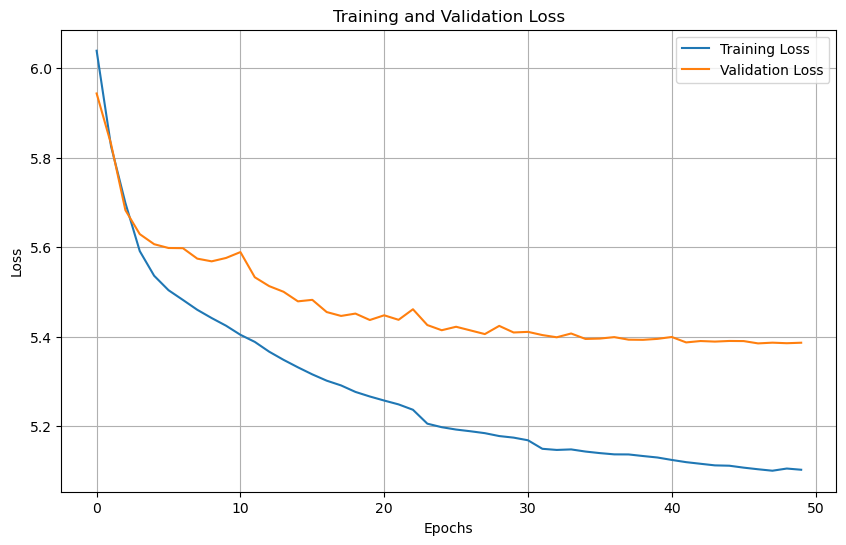

In [73]:
# Initialize model
vocab_size = len(vocab)
embedding_dim = 300  # Word2Vec dimension
melody_dim = 7  # Number of melody features
hidden_dim = 512

model = LyricsMelodyGeneratorSimple(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    melody_dim=melody_dim,
    hidden_dim=hidden_dim,
    num_layers=4,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix
).to(device)

# Train model
print("Training model...")
trained_model, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    learning_rate=0.0001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Test Set Evaluation - Simple Model

In [33]:
def generate_lyrics_for_test(model, melody_data, reverse_vocab, start_words,
                             max_length=50, temperature=0.8, device='cpu'):
    """
    Generate lyrics for a set of test melodies using different starting words.
    Consecutive <NEXT LINE> tokens produce only one newline in the output.

    Args:
        model: a trained lyrics‐generation model with .generate_lyrics(...)
        melody_data: numeric features for the melody
        reverse_vocab: dict mapping token IDs back to strings
        start_words: list of tokens to seed generation with (e.g. ['<START>'])
        max_length: max number of tokens to generate
        temperature: sampling temperature
        device: 'cpu' or 'cuda'

    Returns:
        dict mapping each start_word to its generated lyrics string.
    """
    generated_lyrics = {}

    for start_word in start_words:
        # 1) generate raw token list
        lyrics = model.generate_lyrics(
            melody_data, reverse_vocab,
            max_length=max_length,
            start_word=start_word,
            temperature=temperature,
            device=device
        )

        # 2) collapse repeated <NEXT LINE> into one '\n', drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False
        for token in lyrics:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        # 3) join everything with spaces, then remove spaces around newlines
        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        # 4) strip any leading/trailing whitespace/newlines
        generated_lyrics[start_word] = formatted_text.strip()

    return generated_lyrics

In [34]:
# Check if test mappings are available
if 'test_mapping' in locals() and len(test_mapping) > 0 and 'trained_model' in locals():
    # Set start words for generation
    start_words = ['<START>']

    # Results dictionary
    all_test_results_simple = {}

    for test_item in test_mapping:
        print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

        # Extract melody features
        midi_features = load_midi_features(test_item['midi_file'])
        if midi_features is None:
            print(f"Error: Could not extract features from {test_item['midi_file']}")
            continue

        # Prepare melody features for simple model
        melody_feats = np.array([
            midi_features.get('avg_pitch', 0),
            midi_features.get('pitch_std', 0),
            midi_features.get('pitch_range', 0),
            midi_features.get('avg_duration', 0),
            midi_features.get('avg_velocity', 0),
            midi_features.get('note_density', 0),
            midi_features.get('tempo', 120) / 120.0,
        ])

        # Generate lyrics with simple model
        test_results = generate_lyrics_for_test(
            model=trained_model,
            melody_data=melody_feats,
            reverse_vocab={v: k for k, v in vocab.items()},
            start_words=start_words,
            max_length=250,
            temperature=0.8,
            device=device
        )

        all_test_results_simple[f"{test_item['artist']} - {test_item['song']}"] = test_results

        # Print generated lyrics
        for start_word, lyrics in test_results.items():
            print(f"\nStarting with '{start_word}':")
            print(lyrics)
else:
    print("No test mappings available or model not trained.")

No test mappings available or model not trained.


## 8. Advanced Dataset for Second Approach

In [52]:
class LyricsMelodySequenceDataset(Dataset):
    def __init__(self, mappings, vocab, max_sequence_length=50, context_size=3):
        """
        Dataset for advanced lyrics generation with time-based features.

        Args:
            mappings: List of song mappings (artist, song, lyrics, midi_file)
            vocab: Dictionary mapping words to indices
            max_sequence_length: Maximum sequence length
            context_size: Number of previous words to use as context
        """
        self.mappings = mappings
        self.vocab = vocab
        self.max_sequence_length = max_sequence_length
        self.context_size = context_size
        self.reverse_vocab = {v: k for k, v in vocab.items()}

        # Preprocess all data
        self.process_all_data()

    def process_all_data(self):
        self.data = []

        for mapping in tqdm(self.mappings, desc="Processing advanced data"):
            try:
                midi = pretty_midi.PrettyMIDI(mapping["midi_file"])
                total_dur = midi.get_end_time()
                raw_lines = str(mapping["lyrics"]).lower().split("&")

                # 1) compute per‑line durations & tokenized lines
                line_durations, tokenized_lines = allocate_line_durations(raw_lines, total_dur)

                # 2) begin global containers
                full_tokens = ["<START>"]
                all_word_features = [("<END>", {  # dummy feature for START
                    "pitch_mean": 0, "pitch_std": 0, "velocity_mean": 0,
                    "duration_mean": 0, "note_density": 0,
                    "local_notes": [], "context_before": [], "context_after": []
                })]

                # 3) walk through lines, keeping an absolute‑time cursor
                current_t = 0.0
                for tokens, ln_dur in zip(tokenized_lines, line_durations):
                    if not tokens:  # empty line – just advance the clock
                        current_t += ln_dur
                        continue

                    word_timings = estimate_word_durations(tokens, ln_dur, current_t)
                    feats = extract_time_based_features(midi, word_timings)

                    full_tokens.extend(tokens)
                    all_word_features.extend(feats)

                    # explicit line break token
                    full_tokens.append("<NEXT LINE>")
                    all_word_features.append(feats[-1])  # reuse last feat

                    current_t += ln_dur  # advance clock

                # 4) final END token
                full_tokens.append("<END>")
                all_word_features.append(all_word_features[0])  # same dummy

                # 5) slide a context window to build examples
                for i in range(self.context_size, len(full_tokens)):
                    ctx_w = full_tokens[i - self.context_size:i]
                    tgt_w = full_tokens[i]
                    ctx_f = [all_word_features[j][1] for j in range(i - self.context_size, i)]
                    tgt_f = all_word_features[i][1]

                    self.data.append({
                        "context_words": ctx_w,
                        "context_features": ctx_f,
                        "target_word": tgt_w,
                        "target_features": tgt_f,
                    })

            except Exception as e:
                print(f"Error processing {mapping['artist']} – {mapping['song']}: {e}")
                continue

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Convert words to indices
        context_indices = [self.vocab[w] for w in item['context_words']]
        target_index = self.vocab[item['target_word']]

        # Extract relevant features
        context_features = []
        for features in item['context_features']:
            # Create a fixed-size feature vector for each context word
            feature_vector = np.array([
                features['pitch_mean'] / 127.0,  # Normalize pitch
                features['pitch_std'] / 12.0,  # Normalize std
                features['velocity_mean'] / 127.0,  # Normalize velocity
                features['duration_mean'],  # Duration in seconds
                features['note_density'],  # Notes per second
                len(features['local_notes']),  # Number of notes
                len(features['context_before']),  # Context before
                len(features['context_after'])  # Context after
            ])
            context_features.append(feature_vector)

        # Target features
        target_feature_vector = np.array([[
            item['target_features']['pitch_mean'] / 127.0,
            item['target_features']['pitch_std'] / 12.0,
            item['target_features']['velocity_mean'] / 127.0,
            item['target_features']['duration_mean'],
            item['target_features']['note_density'],
            len(item['target_features']['local_notes']),
            len(item['target_features']['context_before']),
            len(item['target_features']['context_after'])
        ]])

        return {
            'context_words': torch.tensor(context_indices, dtype=torch.long),
            'context_features': torch.tensor(np.array(context_features), dtype=torch.float),
            'target_word': torch.tensor(target_index, dtype=torch.long),
            'target_features': torch.tensor(target_feature_vector, dtype=torch.float)
        }


def allocate_line_durations(lines, total_dur):
    """
    Return a pair (durations, tokenized_lines) where each line gets a share
    of *total_dur* proportional to its letter count.
    """
    tokenized_lines = [re.findall(r"\b\w+(?:'\w+)*\b", ln) for ln in lines]
    letter_counts = [sum(len(tok) for tok in toks) for toks in tokenized_lines]
    tot_letters = sum(letter_counts)

    if tot_letters == 0:  # fallback: equal split
        per = total_dur / max(len(lines), 1)
        return [per] * len(lines), tokenized_lines

    durations = [(cnt / tot_letters) * total_dur for cnt in letter_counts]
    return durations, tokenized_lines


# Helper functions for the advanced dataset and model
def estimate_word_durations(
        tokens, line_duration, start_offset=0.0, word_overhead=0.1):
    """
    Distribute *line_duration* across tokens ∝ their length and return
    absolute timings (courtesy of *start_offset*).
    """
    total_letters = sum(len(w) for w in tokens)
    total_overhead = word_overhead * len(tokens)
    time_per_letter = ((line_duration - total_overhead)
                       / total_letters) if total_letters else 0

    timings, t = [], start_offset
    for w in tokens:
        dur = len(w) * time_per_letter + word_overhead
        timings.append((w, t, t + dur))
        t += dur
    return timings


def extract_time_based_features(midi_data, word_timings):
    """
    Extract MIDI features for each word based on its estimated timing.

    Args:
        midi_data: PrettyMIDI object
        word_timings: List of (word, start_time, end_time) tuples

    Returns:
        List of (word, features) pairs
    """
    word_features = []

    for word, start_time, end_time in word_timings:
        # Initialize features for this word
        features = {
            'local_notes': [],
            'pitch_mean': 0,
            'pitch_std': 0,
            'velocity_mean': 0,
            'note_density': 0,
            'duration_mean': 0,
            'context_before': [],  # notes before this word
            'context_after': []  # notes after this word
        }

        # Context window (how far before/after to look)
        context_window = 1.0  # seconds

        # Collect notes for this word and context
        for instrument in midi_data.instruments:
            # Find notes that overlap with this word's timing
            for note in instrument.notes:
                # Note overlaps with word timing if:
                # (note starts before word ends) AND (note ends after word starts)
                note_overlaps = (note.start < end_time) and (note.end > start_time)

                # Note is in context before if it ends just before word starts
                note_before = (note.end <= start_time) and (note.end > start_time - context_window)

                # Note is in context after if it starts just after word ends
                note_after = (note.start >= end_time) and (note.start < end_time + context_window)

                if note_overlaps:
                    features['local_notes'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'duration': note.end - note.start,
                        'overlap': min(note.end, end_time) - max(note.start, start_time)
                    })

                if note_before:
                    features['context_before'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'time_to_word': start_time - note.end
                    })

                if note_after:
                    features['context_after'].append({
                        'pitch': note.pitch,
                        'velocity': note.velocity,
                        'time_from_word': note.start - end_time
                    })

        # Calculate aggregate features if we have notes
        if features['local_notes']:
            features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
            features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']]) if len(
                features['local_notes']) > 1 else 0
            features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
            features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
            features['note_density'] = len(features['local_notes']) / (
                    end_time - start_time) if end_time > start_time else 0

        # Add to results
        word_features.append((word, features))

    return word_features

## 9. Model Definition - Second Approach (Advanced Melody Integration)

In [53]:
def extract_word_time_features(midi_data, start_time, end_time):
    """Extract features for a word at a specific time window."""
    features = {
        'local_notes': [],
        'pitch_mean': 0,
        'pitch_std': 0,
        'velocity_mean': 0,
        'note_density': 0,
        'duration_mean': 0,
        'context_before': [],
        'context_after': []
    }

    context_window = 1.0  # seconds

    for instrument in midi_data.instruments:
        for note in instrument.notes:
            note_overlaps = (note.start < end_time) and (note.end > start_time)
            note_before = (note.end <= start_time) and (note.end > start_time - context_window)
            note_after = (note.start >= end_time) and (note.start < end_time + context_window)

            if note_overlaps:
                features['local_notes'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'duration': note.end - note.start,
                    'overlap': min(note.end, end_time) - max(note.start, start_time)
                })

            if note_before:
                features['context_before'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'time_to_word': start_time - note.end
                })

            if note_after:
                features['context_after'].append({
                    'pitch': note.pitch,
                    'velocity': note.velocity,
                    'time_from_word': note.start - end_time
                })

    # Calculate aggregate features
    if features['local_notes']:
        features['pitch_mean'] = np.mean([n['pitch'] for n in features['local_notes']])
        features['pitch_std'] = np.std([n['pitch'] for n in features['local_notes']]) if len(
            features['local_notes']) > 1 else 0
        features['velocity_mean'] = np.mean([n['velocity'] for n in features['local_notes']])
        features['duration_mean'] = np.mean([n['duration'] for n in features['local_notes']])
        features['note_density'] = len(features['local_notes']) / (
                end_time - start_time) if end_time > start_time else 0

    return features


def create_feature_vector(features):
    """Create a standardized feature vector from extracted features."""
    return np.array([
        features['pitch_mean'] / 127.0 if features['local_notes'] else 0.5,
        features['pitch_std'] / 12.0 if features['local_notes'] else 0.0,
        features['velocity_mean'] / 127.0 if features['local_notes'] else 0.5,
        features['duration_mean'] if features['local_notes'] else 0.5,
        features['note_density'] if features['local_notes'] else 0.0,
        len(features['local_notes']),
        len(features['context_before']),
        len(features['context_after'])
    ])

In [54]:
# import torch
# import torch.nn.functional as F
#
#
# def sample_top_k(logits, k=50, temperature=1.0):
#     """Return 1 index sampled from the top‑k filtered distribution."""
#     logits = logits / temperature
#     top_logits, top_idx = torch.topk(logits, k)
#     probs = F.softmax(top_logits, dim=-1)
#     choice = torch.multinomial(probs, 1)
#     return top_idx[choice]
#
#
# def sample_top_p(logits, p=0.9, temperature=1.0):
#     """Return 1 index sampled from top‑p (nucleus) distribution."""
#     logits = logits / temperature
#     sorted_logits, sorted_idx = torch.sort(logits, descending=True)
#     probs = F.softmax(sorted_logits, dim=-1)
#     cumulative = probs.cumsum(dim=-1)
#     mask = cumulative > p
#     if mask[..., 0]:
#         mask[..., 0] = False
#     sorted_logits[mask] = -float("Inf")
#     filtered_probs = F.softmax(sorted_logits, dim=-1)
#     choice = torch.multinomial(filtered_probs, 1)
#     return sorted_idx[choice]

In [55]:
## 8. Model Definition - Second Approach (Advanced Melody Integration)
class LyricsMelodyGeneratorAdvanced(nn.Module):
    def __init__(self, vocab_size, embedding_dim, feature_dim, hidden_dim,
                 context_size, num_layers, dropout, pretrained_embeddings, vocab):
        super(LyricsMelodyGeneratorAdvanced, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.context_size = context_size
        self.num_layers = num_layers
        self.vocab = vocab  # Store the vocabulary

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Feature encoder (for musical features)
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM for sequence modeling
        # Input: word embeddings + music features for each context word
        lstm_input_dim = embedding_dim + (hidden_dim // 2)
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer for context words
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        # Calculate the actual dimension after concatenation
        # final hidden state + attention output + target features
        final_dim = hidden_dim + hidden_dim + (hidden_dim // 2)

        # Output layer with the correct input dimension
        self.fc = nn.Sequential(
            nn.Linear(final_dim, hidden_dim),  # Use the actual dimension
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_words, context_features, target_features=None):
        batch_size = context_words.size(0)

        # Word embeddings for context words [batch_size, context_size, embedding_dim]
        word_embeds = self.embedding(context_words)

        # Encode music features for context words [batch_size, context_size, hidden_dim//2]
        music_embeds = self.feature_encoder(context_features)

        # Concatenate word and music embeddings
        combined_input = torch.cat([word_embeds, music_embeds], dim=2)

        # Process with LSTM
        lstm_out, (h_n, c_n) = self.lstm(combined_input)

        # Apply self-attention to get better context representation
        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Take the representation for the last word in context
        final_hidden = h_n[-1]  # [batch_size, hidden_dim]
        last_attn_output = attn_output[:, -1, :]  # [batch_size, hidden_dim]

        # Concatenate final hidden state with attention output
        final_repr = torch.cat([final_hidden, last_attn_output], dim=1)  # [batch_size, hidden_dim*2]

        # If target features provided, incorporate them
        target_music_embed = self.feature_encoder(target_features).view(batch_size,
                                                                        -1)  # [batch_size, hidden_dim//2]
        # Use target music features in the final prediction
        final_repr = torch.cat([final_repr, target_music_embed],
                               dim=1)  # [batch_size, hidden_dim*2 + hidden_dim//2]
        # Project to vocabulary size
        output = self.fc(final_repr)

        return output

    def generate_lyrics(self, midi_data, reverse_vocab, max_length=50,
                        start_words=None, temperature=1.0, device='cpu'):
        """
        Generate lyrics using the advanced model.

        Args:
            midi_data: PrettyMIDI object
            reverse_vocab: Dictionary mapping indices to words
            max_length: Maximum length of generated sequence
            start_words: List of words to start with (should be context_size words)
            temperature: Sampling temperature
            device: Device to run generation on

        Returns:
            List of generated words
        """
        if start_words is None:
            start_words = ['<START>'] * self.context_size
        elif len(start_words) < self.context_size:
            # Pad with START tokens if needed
            start_words = ['<START>'] * (self.context_size - len(start_words)) + start_words

        # Output sequence starts with the context words
        output_words = list(start_words)

        # Convert start words to indices
        context_indices = [self.vocab[w] for w in start_words]
        context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

        # Estimate timing for the sequence
        total_duration = midi_data.get_end_time()
        # Assuming the generation will be about 50 words
        estimated_word_count = max_length
        word_duration = total_duration / estimated_word_count

        # Initial context positions (start at beginning of the song)
        current_time = 0.0
        word_timings = [(word, current_time, current_time + word_duration)
                        for word in start_words]
        current_time += word_duration * len(start_words)

        # Extract features for the context words
        context_features_list = []
        for _, start_time, end_time in word_timings:
            features = extract_word_time_features(midi_data, start_time, end_time)
            feature_vector = create_feature_vector(features)
            context_features_list.append(feature_vector)

        context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        # ── inside LyricsMelodyGeneratorAdvanced.generate_lyrics ──────────────────
        for _ in range(max_length - len(start_words)):
            # 1️⃣  build the feature vector for the *next* time window
            tgt_start = current_time
            tgt_end = current_time + word_duration
            tgt_feat_vec = create_feature_vector(extract_word_time_features(midi_data, tgt_start, tgt_end))
            tgt_feat = torch.tensor([[tgt_feat_vec]], dtype=torch.float, device=device)  # [1,1,feature_dim]

            # 2️⃣  forward pass *with* real target features
            with torch.no_grad():
                output = self.forward(context_tensor, context_features, tgt_feat)

            # 3️⃣  temperature & sampling stay exactly as you had them
            output = output.div(temperature)
            word_weights = output.squeeze().exp()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = reverse_vocab[word_idx]

            if word == '<END>':
                break

            # 4️⃣  update buffers exactly like before
            output_words.append(word)
            context_indices = context_indices[1:] + [word_idx]
            context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

            # 5️⃣  advance the clock and roll context features
            next_timing = (word, current_time, tgt_end)  # optional bookkeeping
            current_time += word_duration  # shift to the next slot

            context_features_list = context_features_list[1:] + [tgt_feat_vec]
            context_features = torch.tensor([context_features_list],
                                            dtype=torch.float).to(device)

        return output_words

## 10. Train Advanced Model

In [56]:
def train_advanced_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the advanced model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            context_words = batch['context_words'].to(device)
            context_features = batch['context_features'].to(device)
            target_word = batch['target_word'].to(device)
            target_features = batch['target_features'].to(device)

            outputs = model(context_words, context_features, target_features)
            loss = criterion(outputs, target_word)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                context_words = batch['context_words'].to(device)
                context_features = batch['context_features'].to(device)
                target_word = batch['target_word'].to(device)
                target_features = batch['target_features'].to(device)

                outputs = model(context_words, context_features, target_features)
                loss = criterion(outputs, target_word)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

In [57]:
# Create the advanced dataset
print("Creating advanced dataset...")
context_size = 3  # Number of context words
advanced_dataset = LyricsMelodySequenceDataset(train_mapping, vocab, context_size=context_size)

# Split into train and validation
adv_train_size = int(0.8 * len(advanced_dataset))
adv_val_size = len(advanced_dataset) - adv_train_size
adv_train_dataset, adv_val_dataset = torch.utils.data.random_split(
    advanced_dataset, [adv_train_size, adv_val_size])

# Create data loaders
adv_train_loader = DataLoader(adv_train_dataset, batch_size=64, shuffle=True)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=64)

print(f"Advanced train dataset size: {len(adv_train_dataset)}")
print(f"Advanced validation dataset size: {len(adv_val_dataset)}")

Creating advanced dataset...


Processing advanced data:   0%|          | 1/594 [00:00<02:02,  4.86it/s]C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing advanced data: 100%|██████████| 594/594 [02:30<00:00,  3.95it/s]


Advanced train dataset size: 142768
Advanced validation dataset size: 35692


Training advanced model...


Epoch 1/25 - Validation: 100%|██████████| 558/558 [00:01<00:00, 392.02it/s]


Epoch 1/25, Train Loss: 5.7224, Val Loss: 5.2660
New best model saved!


Epoch 2/25 - Validation: 100%|██████████| 558/558 [00:01<00:00, 391.75it/s]


Epoch 2/25, Train Loss: 5.1348, Val Loss: 4.8980
New best model saved!


...

Epoch 23/25, Train Loss: 2.6871, Val Loss: 4.2854


Epoch 24/25 - Validation: 100%|██████████| 558/558 [00:01<00:00, 322.50it/s]


Epoch 24/25, Train Loss: 2.6741, Val Loss: 4.2958


Epoch 25/25 - Validation: 100%|██████████| 558/558 [00:01<00:00, 343.97it/s]


Epoch 25/25, Train Loss: 2.6536, Val Loss: 4.3324


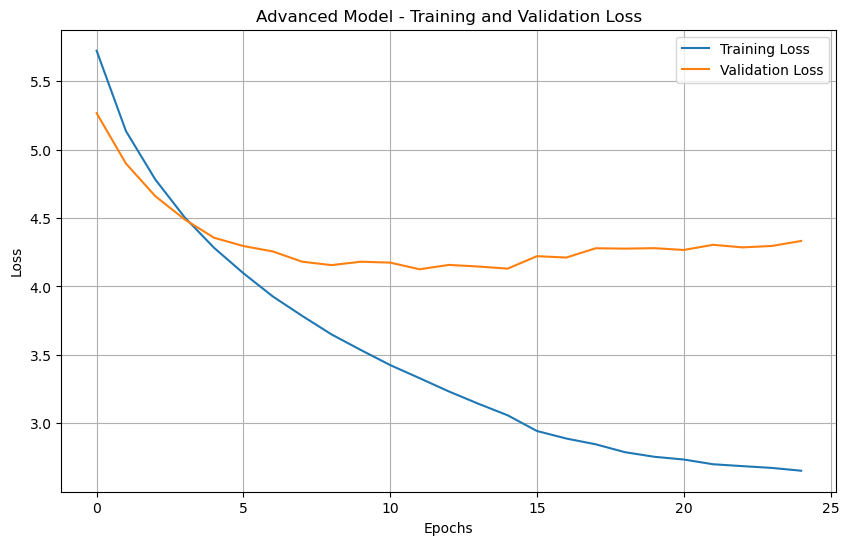

In [58]:
# Initialize the advanced model
vocab_size = len(vocab)
feature_dim = 8  # Our fixed feature vector size
hidden_dim = 512
num_layers = 4

advanced_model = LyricsMelodyGeneratorAdvanced(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    feature_dim=feature_dim,
    hidden_dim=hidden_dim,
    context_size=context_size,
    num_layers=num_layers,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix,
    vocab=vocab  # Pass the vocabulary
).to(device)

# Train the advanced model
print("Training advanced model...")
trained_advanced_model, adv_train_losses, adv_val_losses = train_advanced_model(
    model=advanced_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    epochs=25,
    learning_rate=0.0001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(adv_train_losses, label='Training Loss')
plt.plot(adv_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Advanced Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 11. Generating Lyrics for Test Set

In [61]:
def generate_lyrics_with_advanced_model(model, midi_data, reverse_vocab, start_words,
                                        max_length=50, temperature=0.8, device='cpu'):
    context_size = model.context_size
    generated_lyrics = {}

    for start_word in start_words:
        # 1) generate raw token list
        context = ['<START>'] * (context_size - 1) + [start_word]
        lyrics = model.generate_lyrics(
            midi_data=midi_data,
            reverse_vocab=reverse_vocab,
            max_length=max_length,
            start_words=context,
            temperature=temperature,
            device=device,
        )

        # 2) collapse repeated <NEXT LINE> into one '\n', drop <START>/<END>
        formatted_tokens = []
        prev_was_newline = False
        print(len(lyrics))
        for token in lyrics:
            if token in ('<START>', '<END>'):
                continue
            elif token == '<NEXT LINE>':
                if not prev_was_newline:
                    formatted_tokens.append('\n')
                    prev_was_newline = True
            else:
                formatted_tokens.append(token)
                prev_was_newline = False

        # 3) join everything with spaces, then remove spaces around newlines
        formatted_text = ' '.join(formatted_tokens)
        formatted_text = formatted_text.replace(' \n', '\n').replace('\n ', '\n')

        # 4) strip any leading/trailing whitespace/newlines
        generated_lyrics[start_word] = formatted_text.strip()

    return generated_lyrics

### Test Set Evaluation - Advanced Model

In [62]:
# Check if test mappings are available
if 'test_mapping' in locals() and len(test_mapping) > 0 and 'trained_advanced_model' in locals():
    # Results dictionary
    all_test_results_advanced = {}

    for test_item in test_mapping:  # Limit to first 3 for demonstration
        print(f"\nGenerating lyrics for: {test_item['artist']} - {test_item['song']}")

        # Load MIDI data
        midi_data = pretty_midi.PrettyMIDI(test_item['midi_file'])
        # Generate lyrics with advanced model
        test_results = generate_lyrics_with_advanced_model(
            model=trained_advanced_model,
            midi_data=midi_data,
            reverse_vocab={v: k for k, v in vocab.items()},
            start_words=['<START>'],
            max_length=750,
            temperature=0.9,
            device=device,
        )
        all_test_results_advanced[f"{test_item['artist']} - {test_item['song']}"] = test_results
        # Print generated lyrics
        for start_word, lyrics in test_results.items():
            print(f"\nStarting with '{start_word}':")
            print(lyrics)

else:
    print("No test mappings available or advanced model not trained.")


Generating lyrics for: the_bangles - eternal_flame
8

Starting with '<START>':
let the a ass

Generating lyrics for: billy_joel - honesty
750

Starting with '<START>':
my heart but come your the record rain of my
so is up up huh
you get on the
hey slim stand till baby you can be
oh so so too
but i'm not tha dick cause the fuck is me
who as you did
but if it was say
at his way
and did you look the next that not hey oh oh
we am am
oh oh
if he was the end like like whoa
now when how you did
you got up fed and from your name
y'all gon it'll roll to stay
the time is the man who see and just was an walk you and save to be
yo the like got when you get bone
why want to say fat the star of me
oh my
oh my
in my
i am
mr c
i go no my bag
the get men tits bop
well it that too no be ooh
but i'm the hand at it no
so he for it on the day
i'm the air in the go now
so you tell me what you put you now i'm you like the way i'm to you
my name is the lie
look into all and all she stay
fuck huh
and i'm the 

## 12. Comparative Analysis

In [84]:
if 'all_test_results_simple' in locals() and 'all_test_results_advanced' in locals():
    print("Comparative Analysis of Generated Lyrics\n")


    # Calculate average length of generated lyrics
    def avg_length(lyrics_dict):
        total_length = 0
        count = 0
        for song, results in lyrics_dict.items():
            for start_word, lyrics in results.items():
                words = lyrics.split()
                total_length += len(words)
                count += 1
        return total_length / count if count > 0 else 0


    simple_avg_length = avg_length(all_test_results_simple)
    advanced_avg_length = avg_length(all_test_results_advanced)

    print(f"Simple Model - Average Length: {simple_avg_length:.2f} words")
    print(f"Advanced Model - Average Length: {advanced_avg_length:.2f} words")

    # Display a few sample comparisons
    print("\nSample Comparisons:")

    common_songs = set(all_test_results_simple.keys()) & set(all_test_results_advanced.keys())
    for song in list(common_songs)[:2]:  # Show first 2 common songs
        print(f"\n{song}")

        for start_word in ['<START>']:
            print(f"\nStarting with '{start_word}':")

            if start_word in all_test_results_simple[song]:
                print(f"Simple Model: {all_test_results_simple[song][start_word]}")

            if start_word in all_test_results_advanced[song]:
                print(f"Advanced Model: {all_test_results_advanced[song][start_word]}")
else:
    print("Results from both models not available for comparison.")

Comparative Analysis of Generated Lyrics

Simple Model - Average Length: 11.00 words
Advanced Model - Average Length: 984.00 words

Sample Comparisons:

billy_joel - honesty

Starting with '<START>':
Simple Model: cause we're i want a you the
something
of
on
to
of
of
of
it
to
Advanced Model: to all all in the mind for the soul i'll paint the mouth and the sign and the one and still and then the one don't know what that he's who can't you never have that you're never loved some way and you'll never never know just ever better loved that you're time what's there before that's never just never never matter what you're still before but you're still much much what's much you're like you think that you're something something you're too much you're much i'll remember you love when it's much that you're too much and that's alright you're comin into there you're here it's here cause you're all keep into there you're here inside your eyes and tell you that it's not you're strong cause there's yo

## 13. Save Models and Results

In [85]:
# Save models
if 'trained_model' in locals():
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'simple_lyrics_model.pth')
    print("Simple model saved!")

if 'trained_advanced_model' in locals():
    torch.save({
        'model_state_dict': trained_advanced_model.state_dict(),
        'vocab': vocab,
        'embedding_matrix': embedding_matrix
    }, 'advanced_lyrics_model.pth')
    print("Advanced model saved!")

# Save generated lyrics
if 'all_test_results_simple' in locals() and 'all_test_results_advanced' in locals():
    # Save as text file
    with open('generated_lyrics_results.txt', 'w') as f:
        f.write("==== SIMPLE MODEL RESULTS ====\n\n")
        for song, results in all_test_results_simple.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

        f.write("\n\n==== ADVANCED MODEL RESULTS ====\n\n")
        for song, results in all_test_results_advanced.items():
            f.write(f"Song: {song}\n")
            for start_word, lyrics in results.items():
                f.write(f"Starting with '{start_word}':\n")
                f.write(f"{lyrics}\n\n")

    print("Generated lyrics results saved to 'generated_lyrics_results.txt'")

Simple model saved!
Advanced model saved!
Generated lyrics results saved to 'generated_lyrics_results.txt'
